# 04 Experiments
**Purpose of this notebook:** run the four experiments that answer the three research questions.

| Experiment | Question | Content |
|---|---|---|
| E1 | RQ1 | Feature comparison between human, LLM A and LLM B, with non-parametric tests |
| E2 | RQ2 | Human vs synthetic classification on all 400 texts |
| E3 | RQ3 | Within-model baselines and cross-model generalisation |
| E4 | — | Ablation over feature groups and standardised coefficients |

**Input:** `features.csv` (from 03)
**Output:** result tables in `results/` and figures in `results/figures/`

## Step 1: Setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

os.makedirs("results/figures", exist_ok=True)
plt.rcParams["figure.dpi"] = 200          # >= 150 PPI, required for the poster
plt.rcParams["savefig.bbox"] = "tight"
SEED = 42

In [4]:
from google.colab import files
uploaded = files.upload()

Saving features.csv to features.csv


In [5]:
df = pd.read_csv("features.csv")

FEATURES = ["ttr", "avg_sent_len",
            "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio", "pron_ratio",
            "sent_intensity",
            "comma_rate", "excl_rate", "quest_rate"]

LABELS = {"ttr": "TTR", "avg_sent_len": "Avg. sentence length",
          "noun_ratio": "Noun ratio", "verb_ratio": "Verb ratio",
          "adj_ratio": "Adjective ratio", "adv_ratio": "Adverb ratio",
          "pron_ratio": "Pronoun ratio", "sent_intensity": "Sentiment intensity",
          "comma_rate": "Comma rate", "excl_rate": "Exclamation rate",
          "quest_rate": "Question rate"}

print(len(df), "texts")
print(df["source"].value_counts().to_dict())

400 texts
{'human': 200, 'llm_A': 100, 'llm_B': 100}


# E1 — Feature comparison (RQ1)

Human reviews and their generated counterparts describe the same film with the same sentiment, so the human–LLM comparisons are paired and are tested with the Wilcoxon signed-rank test. The two models were prompted on different films, so LLM A and LLM B are compared with the Mann–Whitney U test. Non-parametric tests are used because the features are not assumed to be normally distributed.

With 11 features and 3 comparisons, 33 tests are performed; the Bonferroni-corrected threshold is therefore 0.05 / 33 = 0.0015.

Effect sizes are reported as rank-biserial correlations, which express how consistently one group exceeds the other independently of sample size.

## E1.1 Descriptive statistics
Medians are reported alongside means, because one human review contains no sentence delimiter and therefore has an extreme sentence-length value.

In [8]:
desc = df.groupby("source")[FEATURES].agg(["mean", "median"]).T.round(3)
desc.to_csv("results/e1_descriptives.csv")
print(desc)

source                  human   llm_A   llm_B
ttr            mean     0.725   0.773   0.823
               median   0.730   0.780   0.820
avg_sent_len   mean    17.754  20.326  15.877
               median  16.183  20.286  15.889
noun_ratio     mean     0.233   0.307   0.312
               median   0.230   0.310   0.314
verb_ratio     mean     0.115   0.130   0.135
               median   0.113   0.128   0.133
adj_ratio      mean     0.090   0.109   0.139
               median   0.090   0.108   0.137
adv_ratio      mean     0.065   0.044   0.056
               median   0.064   0.043   0.058
pron_ratio     mean     0.110   0.056   0.057
               median   0.110   0.056   0.055
sent_intensity mean     0.793   0.838   0.867
               median   0.909   0.942   0.962
comma_rate     mean     4.282   6.250   4.782
               median   4.073   6.015   4.711
excl_rate      mean     0.574   0.124   0.015
               median   0.000   0.000   0.000
quest_rate     mean     0.314   0.

## E1.2 Statistical tests

In [9]:
def rank_biserial_paired(x, y):
    d = np.asarray(x) - np.asarray(y)
    d = d[d != 0]
    if len(d) == 0:
        return 0.0
    r = stats.rankdata(np.abs(d))
    return (r[d > 0].sum() - r[d < 0].sum()) / r.sum()

def rank_biserial_unpaired(x, y):
    u = stats.mannwhitneyu(x, y, alternative="two-sided").statistic
    return 2 * u / (len(x) * len(y)) - 1

wide = df.pivot_table(index="review_id", columns="source", values=FEATURES)
hum = df[df.source == "human"].set_index("review_id")
rows = []
for f in FEATURES:
    for grp, model in [("A", "llm_A"), ("B", "llm_B")]:
        ids = hum[hum.llm_group == grp].index
        h = wide[(f, "human")].loc[ids].to_numpy()
        m = wide[(f, model)].loc[ids].to_numpy()
        p = stats.wilcoxon(h, m).pvalue
        rows.append({"feature": LABELS[f], "comparison": f"Human vs {model}", "test": "Wilcoxon",
                     "p": p, "effect_size": rank_biserial_paired(m, h)})
    a = df[df.source == "llm_A"][f].to_numpy()
    b = df[df.source == "llm_B"][f].to_numpy()
    rows.append({"feature": LABELS[f], "comparison": "LLM A vs LLM B", "test": "Mann-Whitney U",
                 "p": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue,
                 "effect_size": rank_biserial_unpaired(a, b)})

tests = pd.DataFrame(rows)
ALPHA = 0.05 / len(tests)
tests["significant"] = tests["p"] < ALPHA
tests["p"] = tests["p"].apply(lambda v: f"{v:.2e}")
tests["effect_size"] = tests["effect_size"].round(2)
tests.to_csv("results/e1_tests.csv", index=False)
print("Bonferroni threshold:", round(ALPHA, 5), "| tests:", len(tests),
      "| significant:", tests["significant"].sum())
print(tests.to_string(index=False))

Bonferroni threshold: 0.00152 | tests: 33 | significant: 25
             feature     comparison           test        p  effect_size  significant
                 TTR Human vs llm_A       Wilcoxon 1.05e-09         0.73         True
                 TTR Human vs llm_B       Wilcoxon 4.85e-18         1.00         True
                 TTR LLM A vs LLM B Mann-Whitney U 2.78e-19        -0.73         True
Avg. sentence length Human vs llm_A       Wilcoxon 9.73e-04         0.38         True
Avg. sentence length Human vs llm_B       Wilcoxon 5.48e-01         0.07        False
Avg. sentence length LLM A vs LLM B Mann-Whitney U 1.80e-30         0.94         True
          Noun ratio Human vs llm_A       Wilcoxon 4.94e-14         0.87         True
          Noun ratio Human vs llm_B       Wilcoxon 3.14e-17         0.97         True
          Noun ratio LLM A vs LLM B Mann-Whitney U 3.46e-01        -0.08        False
          Verb ratio Human vs llm_A       Wilcoxon 2.68e-05         0.49        

## E1.3 Figure 1 — feature distributions
Four features are shown. Boxplots are used so that the distribution, not only the mean, is visible.

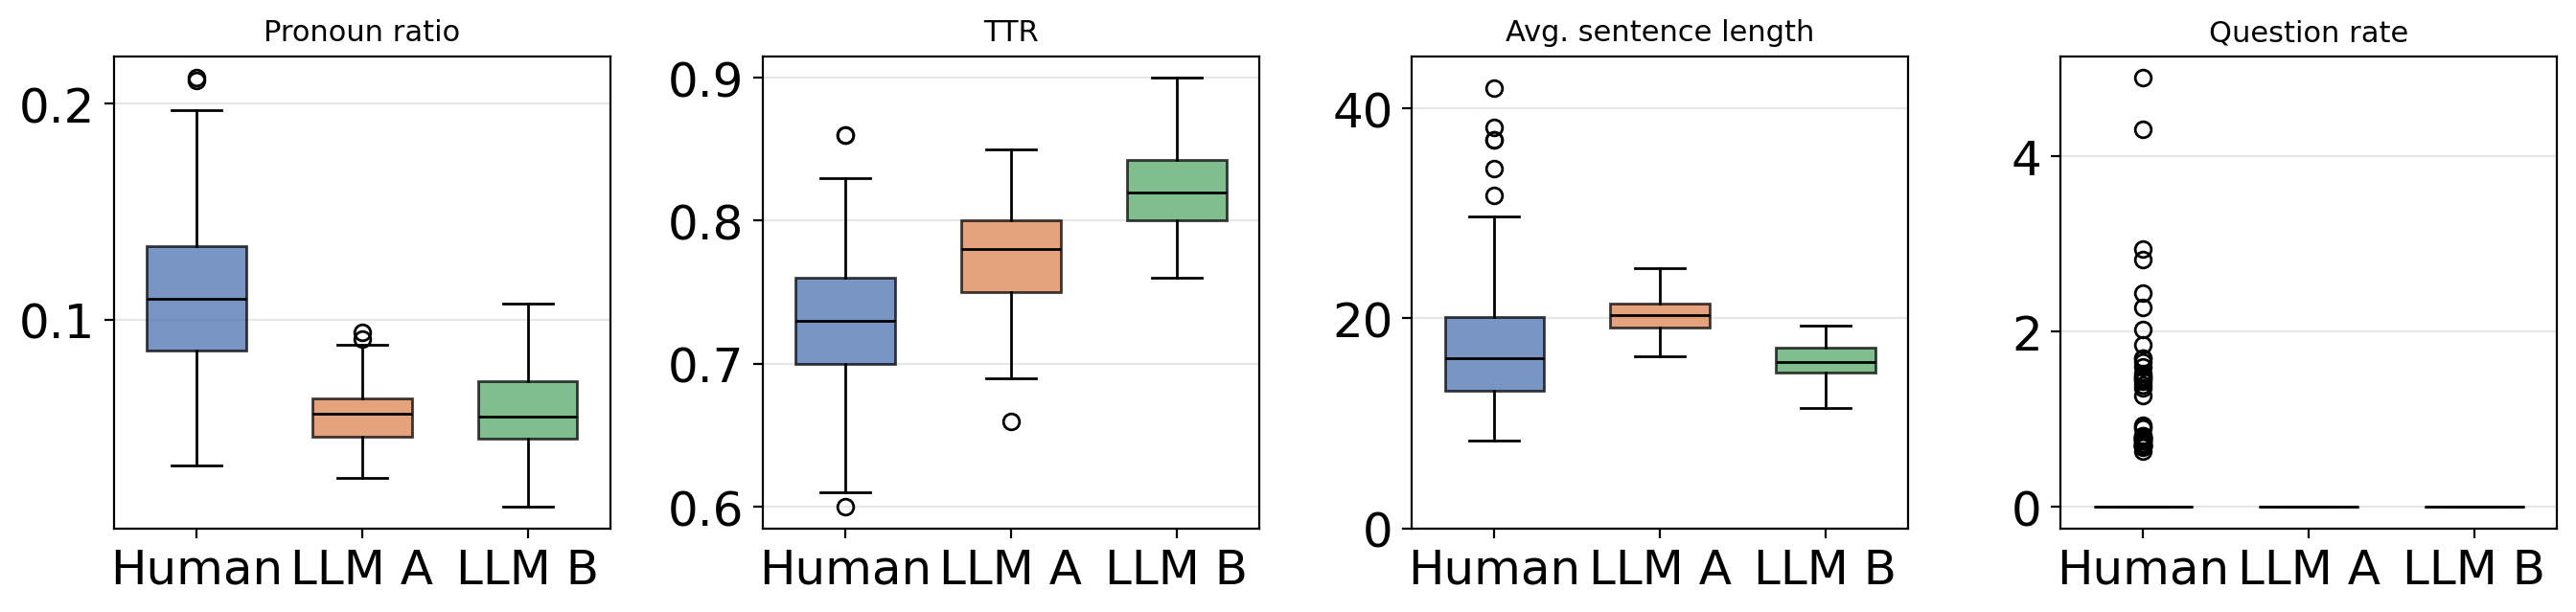

In [6]:
SHOW = ["pron_ratio", "ttr", "avg_sent_len", "quest_rate"]
order = ["human", "llm_A", "llm_B"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

plt.rcParams.update({
    "font.size": 20, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
})

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, f in zip(axes, SHOW):
    data = [df[df.source == s][f].to_numpy() for s in order]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    ax.set_xticks([1, 2, 3], ["Human", "LLM A", "LLM B"])
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(LABELS[f], fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    if f == "avg_sent_len":
        ax.set_ylim(0, 45)          # 截断以显示主体分布；异常值在正文中说明
plt.tight_layout()
plt.savefig("results/figures/fig1_features.png")
plt.show()

# E2 — Human vs synthetic classification (RQ2)

A logistic regression with standardised inputs is evaluated with five-fold cross-validation. Folds are stratified by class and grouped by film ID, so that a human review and its generated counterpart always fall into the same fold. This prevents the classifier from recognising a test item through the film it describes.

Chance level is 50 %, as both classes contain 200 texts.

In [10]:
def make_model():
    return Pipeline([("scale", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=1000, random_state=SEED))])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
X, y, g = df[FEATURES], df["is_llm"], df["tconst"]

scores = cross_validate(make_model(), X, y, groups=g, cv=cv,
                        scoring=["accuracy", "precision", "recall", "f1"])
e2 = pd.DataFrame({m: [scores[f"test_{m}"].mean(), scores[f"test_{m}"].std()]
                   for m in ["accuracy", "precision", "recall", "f1"]},
                  index=["mean", "sd"]).T.round(3)
e2.to_csv("results/e2_scores.csv")
print(e2)

            mean     sd
accuracy   0.942  0.024
precision  0.938  0.042
recall     0.950  0.039
f1         0.943  0.024


## E2.1 Confusion matrix
Built from out-of-fold predictions, so that every text is predicted by a model that has not seen it.

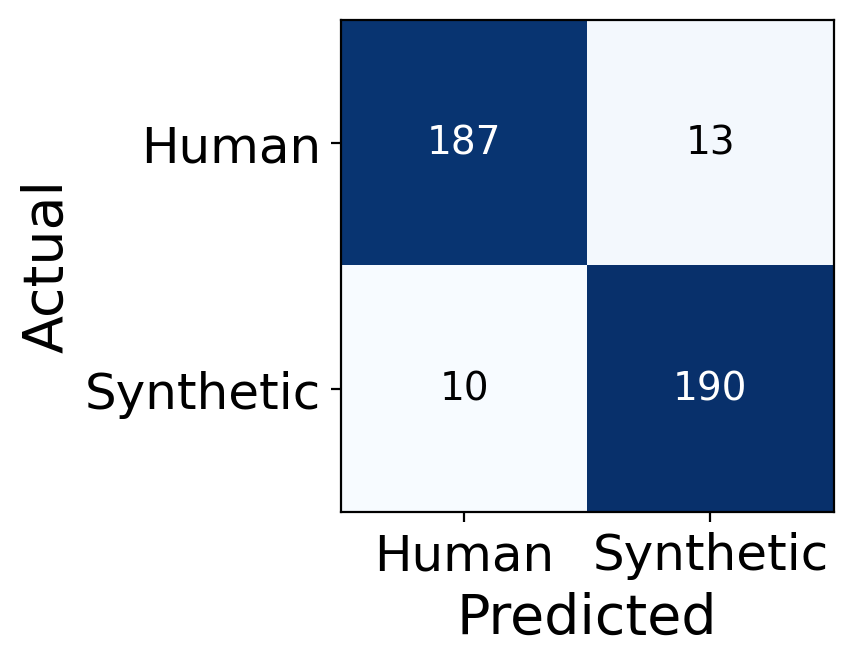

[[187  13]
 [ 10 190]]


In [11]:
pred = cross_val_predict(make_model(), X, y, groups=g, cv=cv)
cm = confusion_matrix(y, pred)

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1], ["Human", "Synthetic"])
ax.set_yticks([0, 1], ["Human", "Synthetic"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.savefig("results/figures/fig2_confusion.png")
plt.show()

df["pred"] = pred          # 供 05 error analysis 使用
df[["text_id", "source", "is_llm", "pred"]].to_csv("results/e2_predictions.csv", index=False)
print(cm)

## E2.2 Robustness check
One human review consists of a single unpunctuated sentence, giving it an extreme sentence-length value. The experiment is repeated without this review and its generated counterpart to confirm that the result does not depend on that single observation.

In [12]:
outlier_tconst = df.loc[df["avg_sent_len"].idxmax(), "tconst"]
sub = df[df["tconst"] != outlier_tconst]
s2 = cross_validate(make_model(), sub[FEATURES], sub["is_llm"], groups=sub["tconst"],
                    cv=cv, scoring=["accuracy", "f1"])
print("Full dataset   accuracy:", round(scores["test_accuracy"].mean(), 3))
print("Outlier removed accuracy:", round(s2["test_accuracy"].mean(), 3), f"(n={len(sub)})")

Full dataset   accuracy: 0.942
Outlier removed accuracy: 0.957 (n=398)


# E3 — Cross-model generalisation (RQ3)

Group A contains 100 human reviews and their 100 LLM A counterparts; group B contains the other 100 human reviews and their 100 LLM B counterparts. Because the two groups share no text, training on one and testing on the other measures how well the features transfer to an unseen generator.

Within-group cross-validation provides the matched baseline for that comparison.

In [13]:
A = df[df.llm_group == "A"]
B = df[df.llm_group == "B"]

def within(data):
    s = cross_validate(make_model(), data[FEATURES], data["is_llm"],
                       groups=data["tconst"], cv=cv, scoring=["accuracy", "f1"])
    return s["test_accuracy"].mean(), s["test_f1"].mean()

def transfer(train, test):
    m = make_model().fit(train[FEATURES], train["is_llm"])
    p = m.predict(test[FEATURES])
    return accuracy_score(test["is_llm"], p), f1_score(test["is_llm"], p)

rows = [
    ("Within A (LLM A only)", *within(A)),
    ("Within B (LLM B only)", *within(B)),
    ("A -> B (unseen LLM)", *transfer(A, B)),
    ("B -> A (unseen LLM)", *transfer(B, A)),
]
e3 = pd.DataFrame(rows, columns=["setting", "accuracy", "f1"]).round(3)
e3.to_csv("results/e3_cross_llm.csv", index=False)
print(e3.to_string(index=False))

              setting  accuracy    f1
Within A (LLM A only)     0.930 0.931
Within B (LLM B only)     0.985 0.985
  A -> B (unseen LLM)     0.955 0.956
  B -> A (unseen LLM)     0.805 0.769


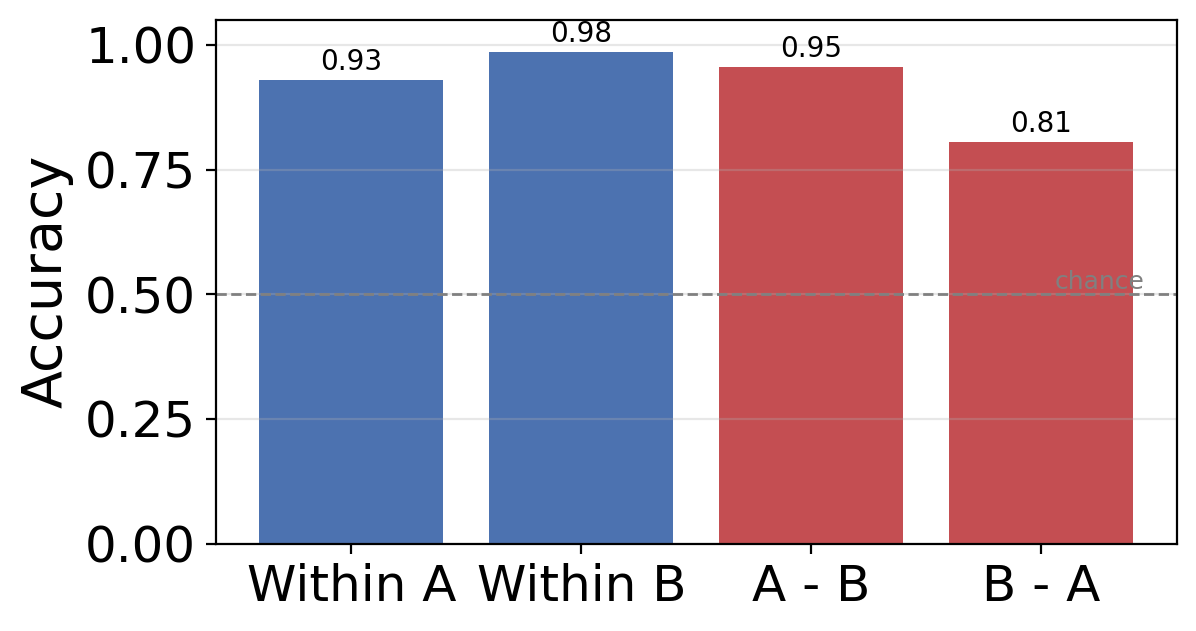

In [14]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
bars = ax.bar(range(4), e3["accuracy"], color=["#4C72B0", "#4C72B0", "#C44E52", "#C44E52"])
ax.axhline(0.5, ls="--", c="grey", lw=1)
ax.text(3.45, 0.51, "chance", color="grey", fontsize=9, ha="right")
ax.set_xticks(range(4), ["Within A", "Within B", "A - B", "B - A"])
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.05)
for b, v in zip(bars, e3["accuracy"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.savefig("results/figures/fig3_cross_llm.png")
plt.show()

# E4 — Ablation and feature weights

Each feature group is evaluated on its own under the same cross-validation scheme as E2, which shows how much of the performance each group carries. The standardised coefficients of a model fitted on all 400 texts indicate the direction and relative weight of every feature; a positive coefficient pushes a text towards the synthetic class.

In [15]:
GROUPS = {
    "Lexical (TTR)": ["ttr"],
    "Sentence length": ["avg_sent_len"],
    "POS ratios": ["noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio", "pron_ratio"],
    "Sentiment": ["sent_intensity"],
    "Punctuation": ["comma_rate", "excl_rate", "quest_rate"],
    "All features": FEATURES,
}
rows = []
for name, cols in GROUPS.items():
    s = cross_validate(make_model(), df[cols], y, groups=g, cv=cv, scoring=["accuracy", "f1"])
    rows.append({"feature_set": name, "n_features": len(cols),
                 "accuracy": s["test_accuracy"].mean(), "f1": s["test_f1"].mean()})
e4 = pd.DataFrame(rows).round(3)
e4.to_csv("results/e4_ablation.csv", index=False)
print(e4.to_string(index=False))

    feature_set  n_features  accuracy    f1
  Lexical (TTR)           1     0.798 0.794
Sentence length           1     0.538 0.529
     POS ratios           5     0.948 0.948
      Sentiment           1     0.543 0.619
    Punctuation           3     0.747 0.774
   All features          11     0.942 0.943


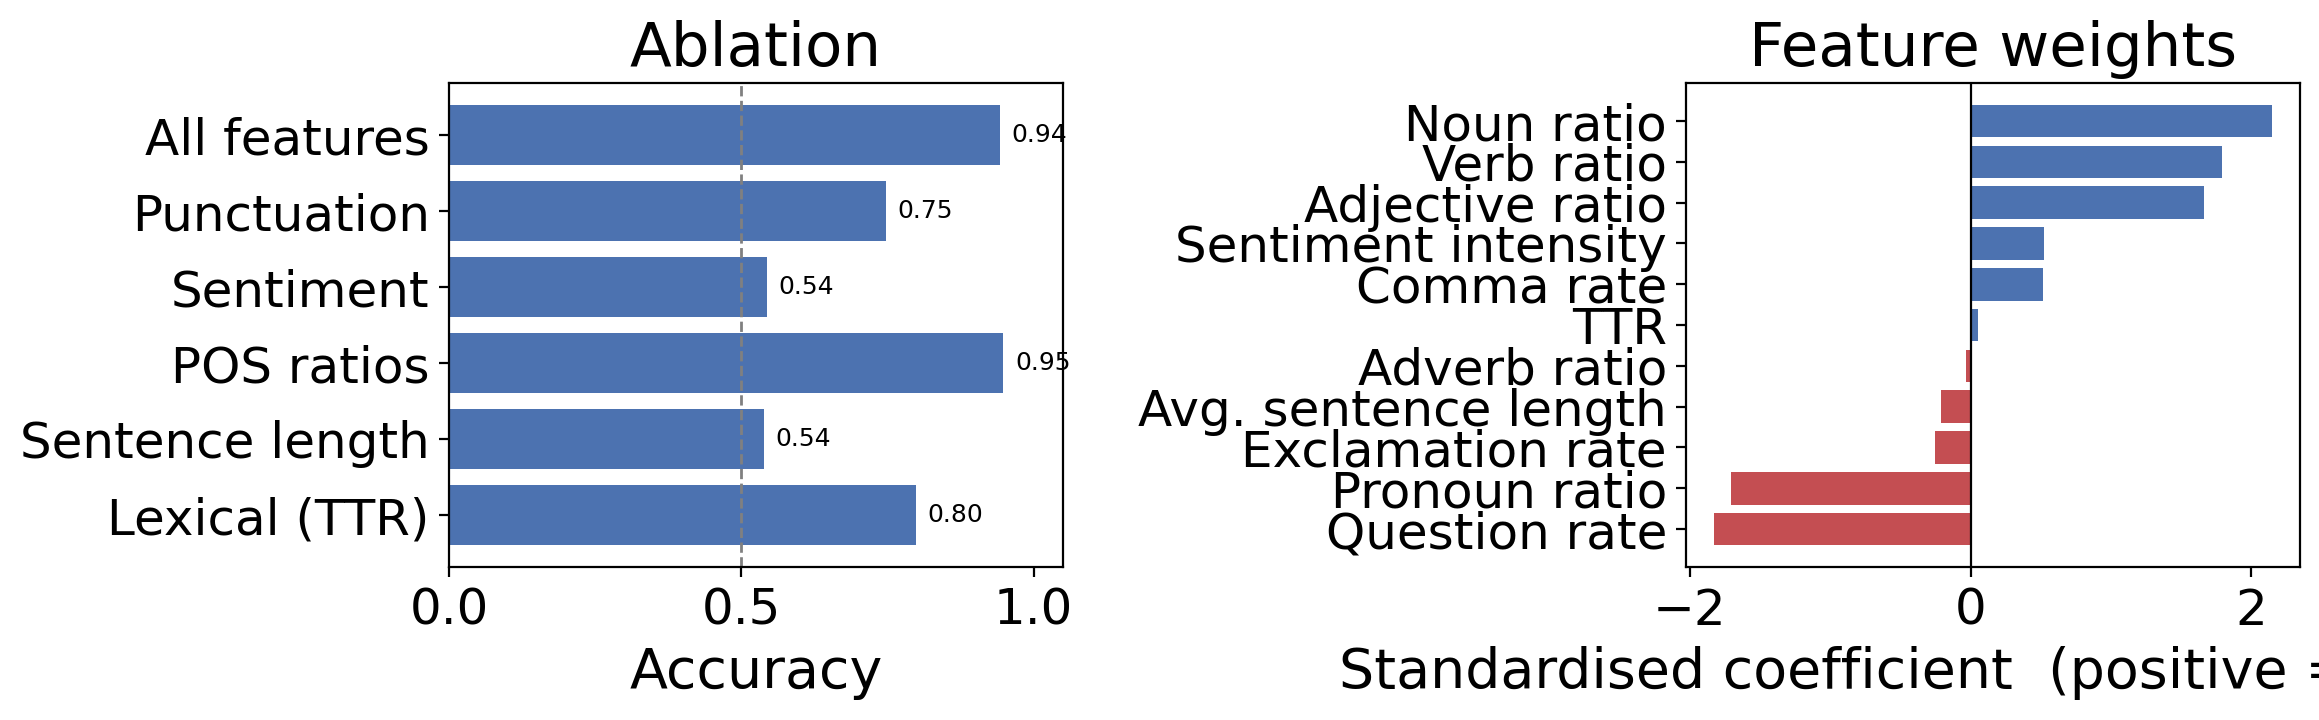

Question rate          -1.83
Pronoun ratio          -1.71
Exclamation rate       -0.25
Avg. sentence length   -0.21
Adverb ratio           -0.03
TTR                     0.05
Comma rate              0.52
Sentiment intensity     0.52
Adjective ratio         1.67
Verb ratio              1.79
Noun ratio              2.15
dtype: float64


In [16]:
model = make_model().fit(X, y)
coef = pd.Series(model.named_steps["clf"].coef_[0], index=[LABELS[f] for f in FEATURES]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.barh(e4["feature_set"], e4["accuracy"], color="#4C72B0")
ax.axvline(0.5, ls="--", c="grey", lw=1)
ax.set_xlabel("Accuracy"); ax.set_xlim(0, 1.05); ax.set_title("Ablation")
for i, v in enumerate(e4["accuracy"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

ax = axes[1]
ax.barh(coef.index, coef.values, color=["#C44E52" if v < 0 else "#4C72B0" for v in coef.values])
ax.axvline(0, c="black", lw=0.8)
ax.set_xlabel("Standardised coefficient  (positive = synthetic)")
ax.set_title("Feature weights")
plt.tight_layout()
plt.savefig("results/figures/fig4_ablation_coefficients.png")
plt.show()
print(coef.round(2))

## Step: Export everything

In [17]:
!zip -qr results.zip results
files.download("results.zip")
files.download("results/e2_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>